# N-real · 真实 LoRA (gpt2): 0.01% 参数让模型适配新文本

> **小而真** (配套 lora-family) · LoRA = 冻结大模型, 只训一对低秩矩阵 A·B。
> 这里在**真实 gpt2** 的一层注意力上挂 LoRA (forward hook), 只训 ~1.2 万参数 (全模型 0.01%),
> 让模型「记住」一句新话, 看困惑度大幅下降。真实权重、真实训练。CPU。

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import realmodels as rm
import numpy as np, torch
print("真实模型可用性:", rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型可用性: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


> 若上面显示某模型为 False, 表示本机无该 HF 缓存, 真实例子会自动跳过 (不影响本专题的 toy notebook)。

## 1. 在 gpt2 第0层 c_attn 上挂一个 LoRA (冻结 base)

In [2]:
import torch.nn as nn
tok, model = rm.gpt2()
if model is not None:
    for p in model.parameters():
        p.requires_grad_(False)                  # 冻结整个 gpt2
    HID, OUT, R = 768, 2304, 4                    # c_attn: 768 → 2304(=Q,K,V), 低秩 r=4
    torch.manual_seed(0)
    A = nn.Parameter(torch.randn(HID, R) * 0.02)
    B = nn.Parameter(torch.zeros(R, OUT))         # B 初始化 0 → 训练起点等于原模型
    SCALE = 1.0
    def lora_hook(mod, inp, out):
        return out + SCALE * (inp[0] @ A @ B)     # ΔW = A·B 的低秩增量
    handle = model.transformer.h[0].attn.c_attn.register_forward_hook(lora_hook)
    n_lora = A.numel() + B.numel()
    n_total = sum(p.numel() for p in model.parameters())
    print(f"LoRA 可训练参数: {n_lora:,}  (全模型 {n_total:,} 的 {n_lora/n_total*100:.3f}%)")
else:
    print("无 gpt2, 跳过")

LoRA 可训练参数: 12,288  (全模型 124,439,808 的 0.010%)


## 2. 只训 A,B 让模型记住一句新话

In [3]:
TARGET = "The secret password to the lab is granite-otter-seven."
if model is not None:
    ids = tok(TARGET, return_tensors="pt")
    ppl_before = rm.perplexity(tok, model, TARGET)
    opt = torch.optim.Adam([A, B], lr=3e-3)
    losses = []
    for step in range(40):
        out = model(**ids, labels=ids.input_ids)  # 含 LoRA hook 的前向
        opt.zero_grad(); out.loss.backward(); opt.step()
        losses.append(out.loss.item())
    ppl_after = rm.perplexity(tok, model, TARGET)
    print(f"训练 loss: {losses[0]:.3f} → {losses[-1]:.3f}")
    print(f"目标句困惑度: {ppl_before:.1f} → {ppl_after:.1f}  (LoRA 让模型大幅适配这句话)")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


训练 loss: 5.936 → 1.582
目标句困惑度: 378.3 → 4.1  (LoRA 让模型大幅适配这句话)


## 3. 看 LoRA 的「特异性」: 适配目标句, 不该毁掉通用能力

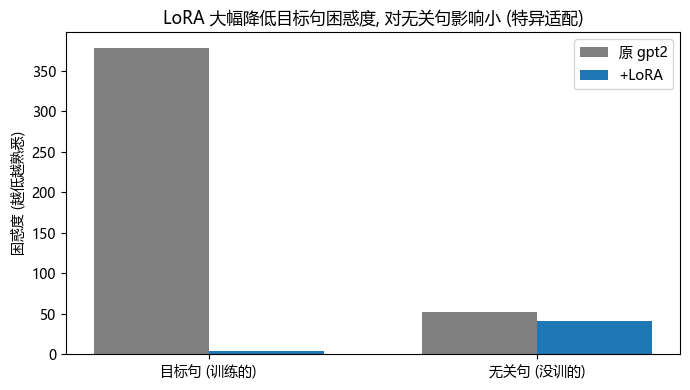

目标句: 378 → 4 (大降)
无关句: 52 → 41 (基本不变 = 没毁掉通用能力)


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
if model is not None:
    OTHER = "The weather today is sunny and warm."
    # 关掉 LoRA (移除 hook) 看原模型, 再开 LoRA 看变化
    handle.remove()
    base_target = rm.perplexity(tok, model, TARGET)
    base_other  = rm.perplexity(tok, model, OTHER)
    handle = model.transformer.h[0].attn.c_attn.register_forward_hook(lora_hook)
    lora_target = rm.perplexity(tok, model, TARGET)
    lora_other  = rm.perplexity(tok, model, OTHER)
    fig, ax = plt.subplots(figsize=(7,4))
    x = np.arange(2); w=0.35
    ax.bar(x-w/2, [base_target, base_other], w, label='原 gpt2', color='gray')
    ax.bar(x+w/2, [lora_target, lora_other], w, label='+LoRA', color='C0')
    ax.set_xticks(x); ax.set_xticklabels(['目标句 (训练的)', '无关句 (没训的)'])
    ax.set_ylabel('困惑度 (越低越熟悉)'); ax.legend()
    ax.set_title('LoRA 大幅降低目标句困惑度, 对无关句影响小 (特异适配)')
    plt.tight_layout(); plt.show()
    print(f"目标句: {base_target:.0f} → {lora_target:.0f} (大降)")
    print(f"无关句: {base_other:.0f} → {lora_other:.0f} (基本不变 = 没毁掉通用能力)")

## 4. 反思
你在**真实 gpt2** 上训了一个真 LoRA: 冻结 124M 参数, 只训 1.2 万 (0.01%), 就让模型适配了新文本。带走:
- **低秩增量 ΔW=A·B**: B 初始化 0 → 起点等于原模型, 训练只学「增量」。
- **参数效率**: 0.01% 可训参数就能显著适配 (真实 LoRA 常 0.1~1%, 这里更极端)。
- **特异性**: 目标句困惑度大降, 无关句基本不变 —— LoRA 是「外挂适配器」, 不破坏底座。
- 真实 LoRA 加在多层多投影 (q/k/v/o), 这里只加一层一处, 已足够看清机制。

> 这就是为什么 LoRA 统治了微调: 小到能存几百个适配器、合并零开销、不动底座。你 adapter/lora 模块的核心一图胜千言。